In [90]:
import numpy as np
from sklearn.linear_model import LinearRegression

print("Libraries imported successfully.")

Libraries imported successfully.


In [91]:
features = ['Area', 'Bedrooms', 'YearBuilt']
X_train_basic = X_train[features]
X_test_basic = X_test[features]

print("Features selected and basic training/testing dataframes created.")
print("X_train_basic head:\n", X_train_basic.head())
print("X_test_basic head:\n", X_test_basic.head())

Features selected and basic training/testing dataframes created.
X_train_basic head:
      Area  Bedrooms  YearBuilt
968  4483         4       1933
240  1062         3       1970
819  1422         3       1993
692  2658         2       1972
420  3286         2       1981
X_test_basic head:
       Area  Bedrooms  YearBuilt
1860   633         1       1901
353   3856         1       1901
1333  1598         5       2013
905   1705         3       1996
1289  2564         5       1994


In [92]:
linear_model = LinearRegression()
linear_model.fit(X_train_basic, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [93]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the RandomForestRegressor model with more estimators and a random state
rf_model_advanced = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the RandomForestRegressor model using the advanced features
rf_model_advanced.fit(X_train_advanced, y_train)

print("RandomForestRegressor model trained successfully with advanced features!")

RandomForestRegressor model trained successfully with advanced features!


In [94]:
y_pred_log = linear_model.predict(X_test_basic)

y_pred = np.expm1(y_pred_log)

print("Predictions on the test set made successfully.")

print("\nFirst 5 predicted house prices:")
print(y_pred[:5])

Predictions on the test set made successfully.

First 5 predicted house prices:
[12.96103925 12.94098017 13.01526075 12.99760582 13.00280397]


In [95]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the RandomForestRegressor model
# Using n_estimators=100 for better performance as suggested
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the RandomForestRegressor model
rf_model.fit(X_train_basic, y_train)

print("RandomForestRegressor model trained successfully!")

RandomForestRegressor model trained successfully!


In [96]:
y_pred_rf_log = rf_model.predict(X_test_basic)
y_pred_rf = np.expm1(y_pred_rf_log)

print("Predictions on the test set using RandomForestRegressor made successfully.")
print("\nFirst 5 predicted house prices (RandomForestRegressor):")
print(y_pred_rf[:5])

Predictions on the test set using RandomForestRegressor made successfully.

First 5 predicted house prices (RandomForestRegressor):
[13.16063085 12.86868715 13.17113801 12.62532111 12.57503976]


In [97]:
print("\n--- Model Performance Comparison ---")
print("\nLinear Regression Model:")
print(f"  Mean Squared Error (MSE): {mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"  Mean Absolute Error (MAE): {mae:.2f}")
print(f"  R-squared (R2 Score): {r2:.2f}")

print("\nRandomForestRegressor Model:")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  R-squared (R2 Score): {r2_rf:.2f}")


--- Model Performance Comparison ---

Linear Regression Model:
  Mean Squared Error (MSE): 0.56
  Root Mean Squared Error (RMSE): 0.75
  Mean Absolute Error (MAE): 0.61
  R-squared (R2 Score): -0.00

RandomForestRegressor Model:
  Mean Squared Error (MSE): 0.63
  Root Mean Squared Error (RMSE): 0.79
  Mean Absolute Error (MAE): 0.64
  R-squared (R2 Score): -0.13


In [98]:
# Define numerical features
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

# Dynamically find existing one-hot encoded 'Location' and 'Condition' columns
# by checking columns present in X_train (assuming X_test has the same columns)
categorical_features = [col for col in X_train.columns if col.startswith('Location_') or col.startswith('Condition_')]

# Combine all features for the advanced model
features_advanced = numerical_features + categorical_features

# Select these features to create the advanced training and testing dataframes
X_train_advanced = X_train[features_advanced]
X_test_advanced = X_test[features_advanced]

print("Advanced features selected and dataframes created successfully.")
print("\nFeatures used for advanced model:", features_advanced)
print("\nX_train_advanced head:\n", X_train_advanced.head())
print("\nX_test_advanced head:\n", X_test_advanced.head())


Advanced features selected and dataframes created successfully.

Features used for advanced model: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor']

X_train_advanced head:
      Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location_Rural  \
968  4483         4          4       3       1933           False   
240  1062         3          3       1       1970           False   
819  1422         3          4       1       1993           False   
692  2658         2          3       1       1972            True   
420  3286         2          4       1       1981            True   

     Location_Suburban  Location_Urban  Condition_Fair  Condition_Good  \
968              False            True           False           False   
240              False           False           False            True   
819              False            True           False            True 

In [99]:
y_pred_rf_advanced_log = rf_model_advanced.predict(X_test_advanced)
y_pred_rf_advanced = np.expm1(y_pred_rf_advanced_log)

print("Predictions on the test set using RandomForestRegressor with advanced features made successfully.")
print("\nFirst 5 predicted house prices (RandomForestRegressor with advanced features):")
print(y_pred_rf_advanced[:5])

Predictions on the test set using RandomForestRegressor with advanced features made successfully.

First 5 predicted house prices (RandomForestRegressor with advanced features):
[13.16754472 12.92409751 12.85822652 12.98426454 12.84459586]


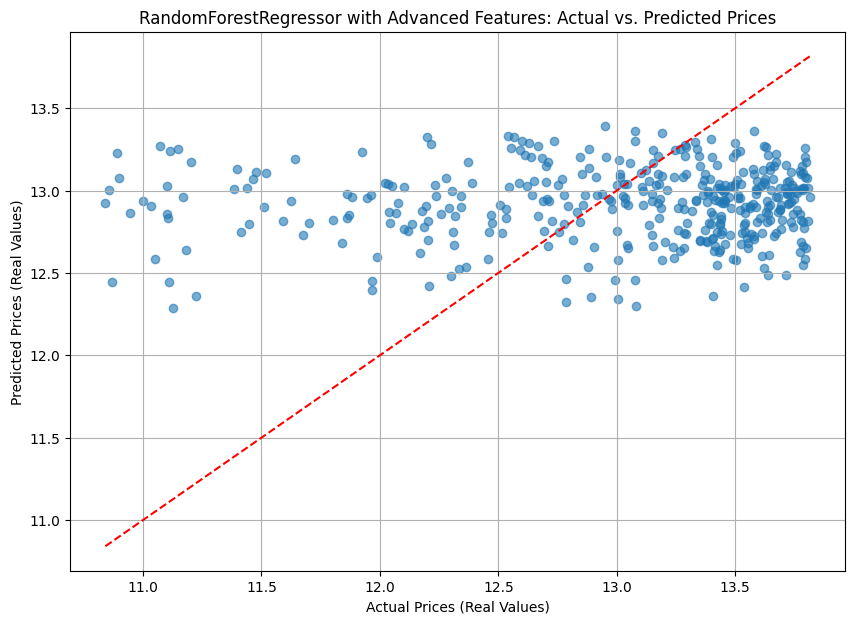

Scatter plot of actual vs. predicted prices using RandomForestRegressor with advanced features generated successfully.


In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(y_test_real, y_pred_rf_advanced, alpha=0.6)
plt.plot([min(y_test_real), max(y_test_real)], [min(y_test_real), max(y_test_real)], color='red', linestyle='--')
plt.title('RandomForestRegressor with Advanced Features: Actual vs. Predicted Prices')
plt.xlabel('Actual Prices (Real Values)')
plt.ylabel('Predicted Prices (Real Values)')
plt.grid(True)
plt.show()

print("Scatter plot of actual vs. predicted prices using RandomForestRegressor with advanced features generated successfully.")

In [101]:
print("\n--- Model Performance Comparison (Linear Regression vs. RandomForestRegressor with Advanced Features) ---")

print("\nLinear Regression Model (with basic features):")
print(f"  Mean Squared Error (MSE): {mse:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"  Mean Absolute Error (MAE): {mae:.2f}")
print(f"  R-squared (R2 Score): {r2:.2f}")

print("\nRandomForestRegressor Model (with advanced features):")
print(f"  Mean Squared Error (MSE): {mse_rf_advanced:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_advanced:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_rf_advanced:.2f}")
print(f"  R-squared (R2 Score): {r2_rf_advanced:.2f}")


--- Model Performance Comparison (Linear Regression vs. RandomForestRegressor with Advanced Features) ---

Linear Regression Model (with basic features):
  Mean Squared Error (MSE): 0.56
  Root Mean Squared Error (RMSE): 0.75
  Mean Absolute Error (MAE): 0.61
  R-squared (R2 Score): -0.00

RandomForestRegressor Model (with advanced features):
  Mean Squared Error (MSE): 0.60
  Root Mean Squared Error (RMSE): 0.77
  Mean Absolute Error (MAE): 0.64
  R-squared (R2 Score): -0.07


In [106]:
import pandas as pd
import numpy as np

print("\n--- Interactive Prediction for Advanced Model ---")

# Get numerical inputs from the user
area_input = float(input("Enter Area (in sq ft): "))
bedrooms_input = int(input("Enter number of Bedrooms: "))
bathrooms_input = int(input("Enter number of Bathrooms: "))
floors_input = int(input("Enter number of Floors: "))
year_built_input = int(input("Enter Year Built: "))

# Get categorical inputs from the user
print("\nSelect Location:")
print("1. Rural")
print("2. Suburban")
print("3. Urban")
location_choice = input("Enter choice (1/2/3): ")

location_map = {
    '1': 'Location_Rural',
    '2': 'Location_Suburban',
    '3': 'Location_Urban'
}
chosen_location_col = location_map.get(location_choice, 'Location_Urban') # Default to Urban if invalid

print("\nSelect Condition:")
print("1. Fair")
print("2. Good")
print("3. Poor")
condition_choice = input("Enter choice (1/2/3): ")

condition_map = {
    '1': 'Condition_Fair',
    '2': 'Condition_Good',
    '3': 'Condition_Poor'
}
chosen_condition_col = condition_map.get(condition_choice, 'Condition_Good') # Default to Good if invalid

# Prepare input for prediction - create a dictionary with all features
new_house_advanced_input = {
    'Area': area_input,
    'Bedrooms': bedrooms_input,
    'Bathrooms': bathrooms_input,
    'Floors': floors_input,
    'YearBuilt': year_built_input
}

# Initialize all one-hot encoded columns to False
for col in features_advanced:
    if col.startswith('Location_') or col.startswith('Condition_'):
        new_house_advanced_input[col] = False

# Set the chosen categorical columns to True
new_house_advanced_input[chosen_location_col] = True
new_house_advanced_input[chosen_condition_col] = True

# Convert to DataFrame, ensuring columns are in the same order as features_advanced
new_house_df_advanced = pd.DataFrame([new_house_advanced_input], columns=features_advanced)

# Make prediction using the advanced RandomForestRegressor model
predicted_log_price_advanced = rf_model_advanced.predict(new_house_df_advanced)
predicted_price_in_millions = np.expm1(predicted_log_price_advanced)[0] # Assuming original target was log1p(price in millions)

# Set final price display to Lakhs
final_price = predicted_price_in_millions * 10 # 1 Million = 10 Lakhs
unit_label = "Lakhs ₹"

print(f"\nPredicted price for the entered house (Advanced Model): {unit_label}{final_price:,.2f}")



--- Interactive Prediction for Advanced Model ---
Enter Area (in sq ft): 4000
Enter number of Bedrooms: 5
Enter number of Bathrooms: 3
Enter number of Floors: 2
Enter Year Built: 2000

Select Location:
1. Rural
2. Suburban
3. Urban
Enter choice (1/2/3): 3

Select Condition:
1. Fair
2. Good
3. Poor
Enter choice (1/2/3): 1

Predicted price for the entered house (Advanced Model): Lakhs ₹129.88
